In [ ]:
#import
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from prettytable import PrettyTable

from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller

from prophet import Prophet

plt.style.use("seaborn-v0_8")

In [ ]:
#read
df = pd.read_csv("../dataset/Electric_Vehicle_Population_Data.csv")
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,WA1E2AFY8R,Thurston,Olympia,WA,98512.0,2024,AUDI,Q5 E,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,23.0,0.0,22.0,263239938,POINT (-122.90787 46.9461),PUGET SOUND ENERGY INC,5.306701e+10
1,WAUUPBFF4J,Yakima,Wapato,WA,98951.0,2018,AUDI,A3,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,16.0,0.0,15.0,318160860,POINT (-120.42083 46.44779),PACIFICORP,5.307794e+10
2,1N4AZ0CP0F,King,Seattle,WA,98125.0,2015,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,0.0,46.0,184963586,POINT (-122.30253 47.72656),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
3,WA1VAAGE5K,King,Kent,WA,98031.0,2019,AUDI,E-TRON,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,204.0,0.0,11.0,259426821,POINT (-122.17743 47.41185),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
4,7SAXCAE57N,Snohomish,Bothell,WA,98021.0,2022,TESLA,MODEL X,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,1.0,208182236,POINT (-122.18384 47.8031),PUGET SOUND ENERGY INC,5.306105e+10


In [ ]:
#check dataset
df.info()
df.describe(include="all")
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264628 entries, 0 to 264627
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         264628 non-null  object 
 1   County                                             264619 non-null  object 
 2   City                                               264619 non-null  object 
 3   State                                              264628 non-null  object 
 4   Postal Code                                        264619 non-null  float64
 5   Model Year                                         264628 non-null  int64  
 6   Make                                               264628 non-null  object 
 7   Model                                              264628 non-null  object 
 8   Electric Vehicle Type                              264628 non-null  object

VIN (1-10)                                             0
County                                                 9
City                                                   9
State                                                  0
Postal Code                                            9
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         4
Base MSRP                                              4
Legislative District                                 659
DOL Vehicle ID                                         0
Vehicle Location                                      17
Electric Utility                                       9
2020 Census Tract                                      9
dtype: int64

In [ ]:
#check missing value
df.isna().sum()

VIN (1-10)                                             0
County                                                 9
City                                                   9
State                                                  0
Postal Code                                            9
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         4
Base MSRP                                              4
Legislative District                                 659
DOL Vehicle ID                                         0
Vehicle Location                                      17
Electric Utility                                       9
2020 Census Tract                                      9
dtype: int64

In [ ]:
#drop missing value
df = df.dropna()

In [ ]:
#fill missing => because using model year
df["Model Year"] = df["Model Year"].fillna(df["Model Year"].median())
df["Base MSRP"] = df["Base MSRP"].fillna(df["Base MSRP"].median())


In [ ]:
#check duplicate => drop
df.duplicated().sum()
df = df.drop_duplicates()

In [ ]:
#chuan hoa => year => int
df["Model Year"] = df["Model Year"].astype(int)


In [ ]:
#chuan hoa => text
df["State"] = df["State"].str.strip()
df["City"] = df["City"].str.strip()

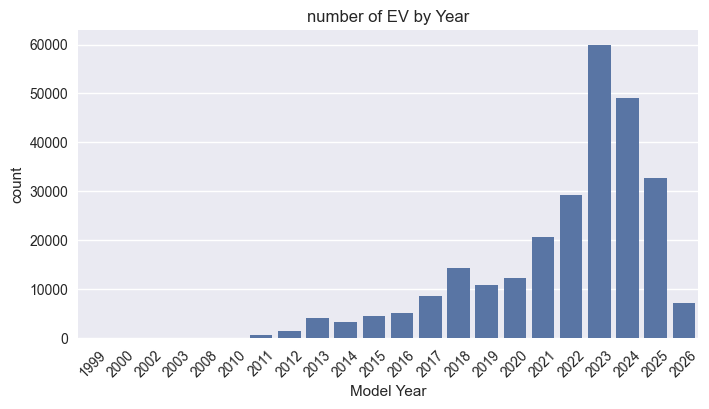

In [ ]:
#EDA
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Model Year")
plt.title("number of EV by Year")
plt.xticks(rotation=45)
plt.show()

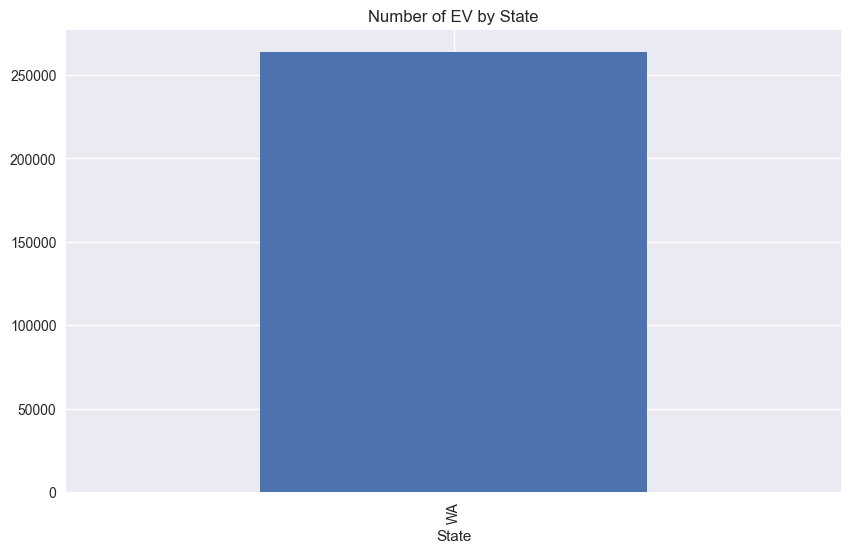

In [ ]:
plt.figure(figsize=(10,6))
df["State"].value_counts().plot(kind="bar")
plt.title("Number of EV by State")
plt.show()


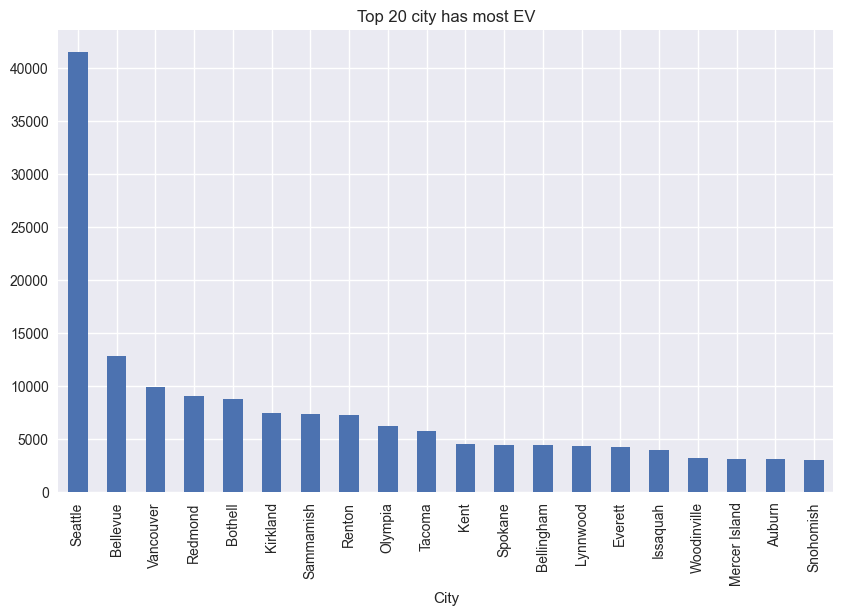

In [ ]:
plt.figure(figsize=(10,6))
df["City"].value_counts().head(20).plot(kind="bar")
plt.title("Top 20 city has most EV")
plt.show()


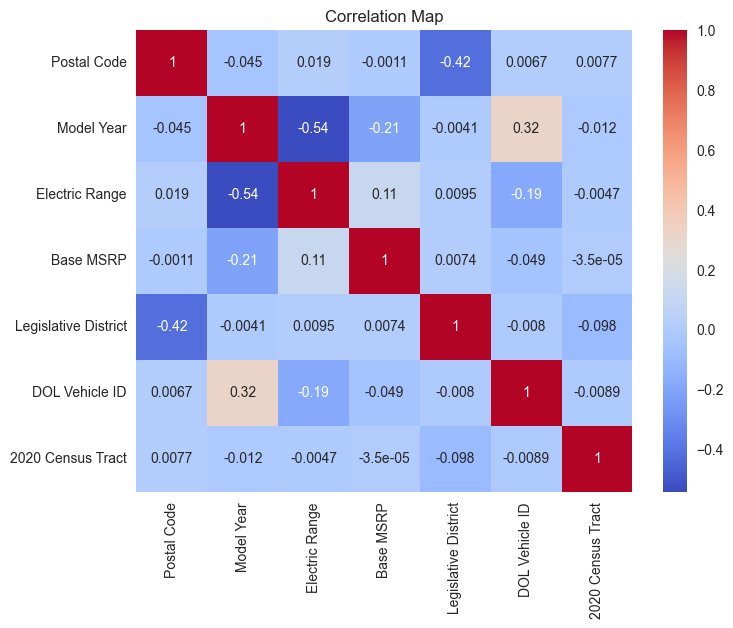

In [ ]:
#corelation (numeric)
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Map")
plt.show()


In [ ]:
ev_year = df.groupby("Model Year").size().reset_index(name="EV_Count")
ev_year

,Model Year,EV_Count
0,1999,2
1,2000,8
2,2002,1
3,2003,1
4,2008,20
5,2010,22
6,2011,622
7,2012,1434
8,2013,4058
9,2014,3282


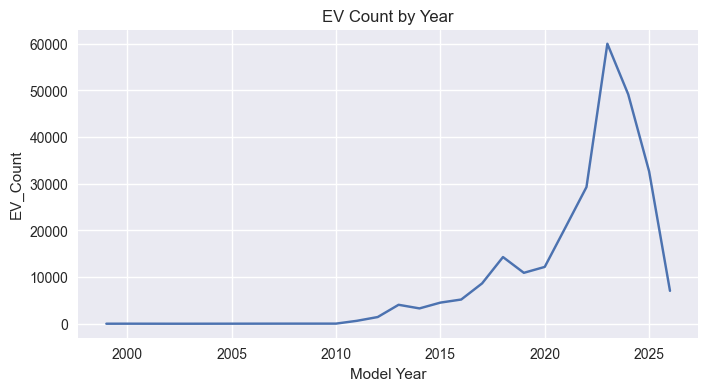

In [ ]:
plt.figure(figsize=(8,4))
sns.lineplot(data=ev_year, x="Model Year",y = "EV_Count")
plt.title("EV Count by Year")
plt.show()

In [ ]:
ev_state = df.groupby("State").size().reset_index(name="EV_Count")
ev_state.sort_values("EV_Count", ascending=False)

,State,EV_Count
0,WA,263957


In [ ]:
ev_city = df.groupby("City").size().reset_index(name="EV_Count")
ev_city.sort_values("EV_Count", ascending=False).head(20)

,City,EV_Count
379,Seattle,41532
26,Bellevue,12843
452,Vancouver,9862
352,Redmond,9035
35,Bothell,8721
197,Kirkland,7463
374,Sammamish,7345
353,Renton,7234
302,Olympia,6212
424,Tacoma,5774


In [ ]:


output_file_path = "../outputs/Electric_Vehicle_Population_Data_CLEANED_FINAL.csv"


df.to_csv(
    output_file_path, 
    index=False,        
    encoding='utf-8'
)


In [ ]:
# ================================
# II. CLASSIFICATION BEV / PHEV
# ================================

In [ ]:

df_clf = df.copy()

#only chose numeric and revelant
features = ["Model Year", "Base MSRP"]

X = df_clf[features]
y = df_clf["Electric Vehicle Type"]

# encode bev/phev label to 0/1
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# khoi tao model
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

# table comparing
table = PrettyTable()
table.field_names = ["Model", "Accuracy", "Precision", "Recall", "F1"]

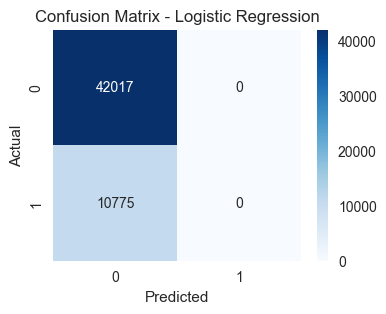

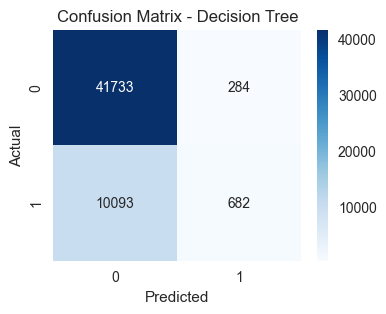

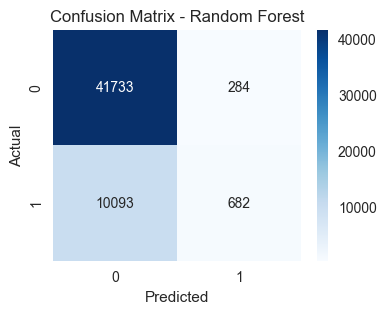

+---------------------+----------+-----------+--------+--------+
|        Model        | Accuracy | Precision | Recall |   F1   |
+---------------------+----------+-----------+--------+--------+
| Logistic Regression |  0.7959  |    0.0    |  0.0   |  0.0   |
|    Decision Tree    |  0.8034  |   0.706   | 0.0633 | 0.1162 |
|    Random Forest    |  0.8034  |   0.706   | 0.0633 | 0.1162 |
+---------------------+----------+-----------+--------+--------+


In [ ]:
# 3. Train and review model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    table.add_row([name, 
                   round(acc, 4),
                   round(pre, 4),
                   round(rec, 4),
                   round(f1, 4)
                  ])

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# print
print(table)

In [ ]:
# ================================
# III. TIME SERIES FORECASTING
# ================================

In [ ]:
# train-testSplit not shuffle 
train_size = int(len(ev_year) * 0.8)

train = ev_year.iloc[:train_size]
test = ev_year.iloc[train_size:]

train, test

(    Model Year  EV_Count
 0         1999         2
 1         2000         8
 2         2002         1
 3         2003         1
 4         2008        20
 5         2010        22
 6         2011       622
 7         2012      1434
 8         2013      4058
 9         2014      3282
 10        2015      4521
 11        2016      5187
 12        2017      8645
 13        2018     14284
 14        2019     10907
 15        2020     12172
 16        2021     20697,
     Model Year  EV_Count
 17        2022     29286
 18        2023     59989
 19        2024     49133
 20        2025     32642
 21        2026      7044)

In [ ]:
# train model arima
arima_model = ARIMA(train["EV_Count"], order=(1,1,1))
arima_fit = arima_model.fit()

print(arima_fit.summary())


                               SARIMAX Results                                
Dep. Variable:               EV_Count   No. Observations:                   17
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -148.958
Date:                Thu, 25 Dec 2025   AIC                            303.916
Time:                        17:49:23   BIC                            306.234
Sample:                             0   HQIC                           304.035
                                 - 17                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4293      0.208     -2.062      0.039      -0.837      -0.021
ma.L1          0.9999      0.369      2.713      0.007       0.278       1.722
sigma2      6.407e+06   5.77e-08   1.11e+14      0.0

c:\Users\lequo\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\lequo\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [ ]:
# forecast with arima
arima_forecast = arima_fit.forecast(steps=len(test))

arima_forecast = pd.Series(
    arima_forecast.values,
    index=test["Model Year"].values
)

arima_forecast


2022    23000.351708
2023    22011.411599
2024    22436.011341
2025    22253.710169
2026    22331.980865
dtype: float64

In [ ]:
# Evaluate ARIMA
mae_arima = mean_absolute_error(test["EV_Count"], arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(test["EV_Count"], arima_forecast))

print("Baseline ARIMA MAE:", mae_arima)
print("Baseline ARIMA RMSE:", rmse_arima)


Baseline ARIMA MAE: 19327.299209441244
Baseline ARIMA RMSE: 22521.877022956665


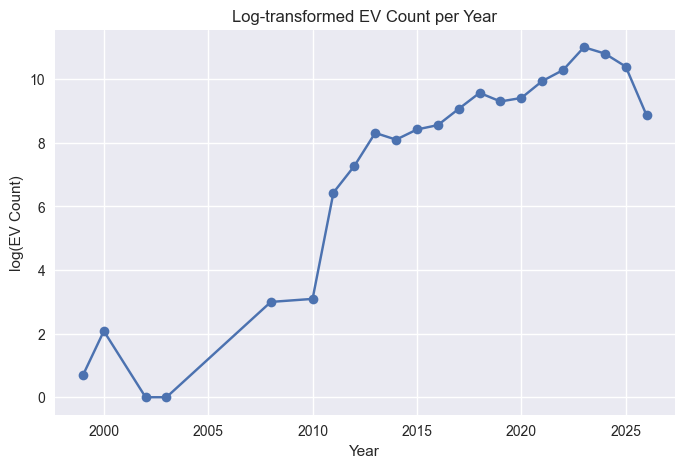

In [ ]:
# arima optimization
ev_year["EV_log"] = np.log(ev_year["EV_Count"])

plt.figure(figsize=(8,5))
plt.plot(ev_year["Model Year"], ev_year["EV_log"], marker='o')
plt.xlabel("Year")
plt.ylabel("log(EV Count)")
plt.title("Log-transformed EV Count per Year")
plt.grid(True)
plt.show()


In [ ]:
# log scale
train_log = ev_year.iloc[:train_size]["EV_log"]
test_log  = ev_year.iloc[train_size:]["EV_log"]


In [ ]:
adf_result = adfuller(train_log)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])


ADF Statistic: -5.673417170735029
p-value: 8.815507316713598e-07


In [ ]:
# find best (p,d,q)
auto_model = auto_arima(
    train_log,
    seasonal=False,
    trace=True,
    stepwise=True,
    suppress_warnings=True
)

auto_model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=55.815, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=57.532, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=57.561, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=57.044, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=59.508, Time=0.04 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 0.229 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   17
Model:               SARIMAX(0, 1, 0)   Log Likelihood                 -25.907
Date:                Thu, 25 Dec 2025   AIC                             55.815
Time:                        17:49:24   BIC                             57.360
Sample:                             0   HQIC                            55.894
                                 - 17                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.5778      0.321      1.801      0.072      -0.051       1.206
sigma2         1.4926      0.449      3.321      0.001       0.612       2.373
===================================================================================
Ljung-Box (L1) (Q):                   0.35   Jarque-Bera (JB):                 1.48
Prob(Q):                              0.56   Prob(JB):                         0.48
Heteroskedasticity (H):               0.07   Skew:                             0.53
Prob(H) (two-sided):                  0.01   Kurtosis:                         4.04
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# train optimized arima
best_order = auto_model.order
best_order


(0, 1, 0)

In [ ]:
arima_opt = ARIMA(train_log, order=best_order, trend='t')
arima_opt_fit = arima_opt.fit()

print(arima_opt_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                 EV_log   No. Observations:                   17
Model:                 ARIMA(0, 1, 0)   Log Likelihood                 -25.907
Date:                Thu, 25 Dec 2025   AIC                             55.815
Time:                        17:49:24   BIC                             57.360
Sample:                             0   HQIC                            55.894
                                 - 17                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.5778      0.321      1.801      0.072      -0.051       1.206
sigma2         1.4926      0.449      3.321      0.001       0.612       2.373
Ljung-Box (L1) (Q):                   0.35   Jarque-

In [ ]:
# forecast & inverse transform
log_forecast = arima_opt_fit.forecast(steps=len(test_log))
arima_forecast_opt = np.exp(log_forecast)

arima_forecast_opt = pd.Series(
    arima_forecast_opt.values,
    index=test["Model Year"].values
)

arima_forecast_opt


2022     36883.751056
2023     65729.868675
2024    117136.015517
2025    208745.984250
2026    372002.460116
dtype: float64

In [ ]:
# evaluate optimized arima

mae_opt = mean_absolute_error(test["EV_Count"], arima_forecast_opt)
rmse_opt = np.sqrt(mean_squared_error(test["EV_Count"], arima_forecast_opt))

print("Optimized ARIMA MAE:", mae_opt)
print("Optimized ARIMA RMSE:", rmse_opt)


Optimized ARIMA MAE: 124480.81592288594
Optimized ARIMA RMSE: 183805.54093551193


In [ ]:
# data prep for prophet
prophet_df = ev_year.rename(columns={
    "Model Year": "ds",
    "EV_Count": "y"
})

prophet_df["ds"] = pd.to_datetime(prophet_df["ds"], format="%Y")
prophet_df


,ds,y,EV_log
0,1999-01-01,2,0.693147
1,2000-01-01,8,2.079442
2,2002-01-01,1,0.000000
3,2003-01-01,1,0.000000
4,2008-01-01,20,2.995732
5,2010-01-01,22,3.091042
6,2011-01-01,622,6.432940
7,2012-01-01,1434,7.268223
8,2013-01-01,4058,8.308446
9,2014-01-01,3282,8.096208


In [ ]:
# train prophet
prophet_model = Prophet()
prophet_model.fit(prophet_df)


17:49:24 - cmdstanpy - INFO - Chain [1] start processing
17:49:24 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
# forecast next 10 year
future = prophet_model.make_future_dataframe(periods=10, freq="YE")
forecast = prophet_model.predict(future)
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]]


,ds,yhat,yhat_lower,yhat_upper
0,1999-01-01,-9868.752270,-24961.014734,4572.515919
1,2000-01-01,-6516.668989,-21247.419406,9266.048571
2,2002-01-01,-7421.359613,-21382.997564,8015.574472
3,2003-01-01,-4020.918176,-18659.881032,12244.865661
4,2008-01-01,5178.999198,-9060.993039,20889.955305
5,2010-01-01,4274.308574,-10562.295277,18886.250627
6,2011-01-01,7674.750012,-8157.095097,22182.578976
7,2012-01-01,11026.833293,-3977.009552,26517.242268
8,2013-01-01,6675.739402,-8744.952238,21213.572303
9,2014-01-01,10122.142671,-5231.598641,24891.927397


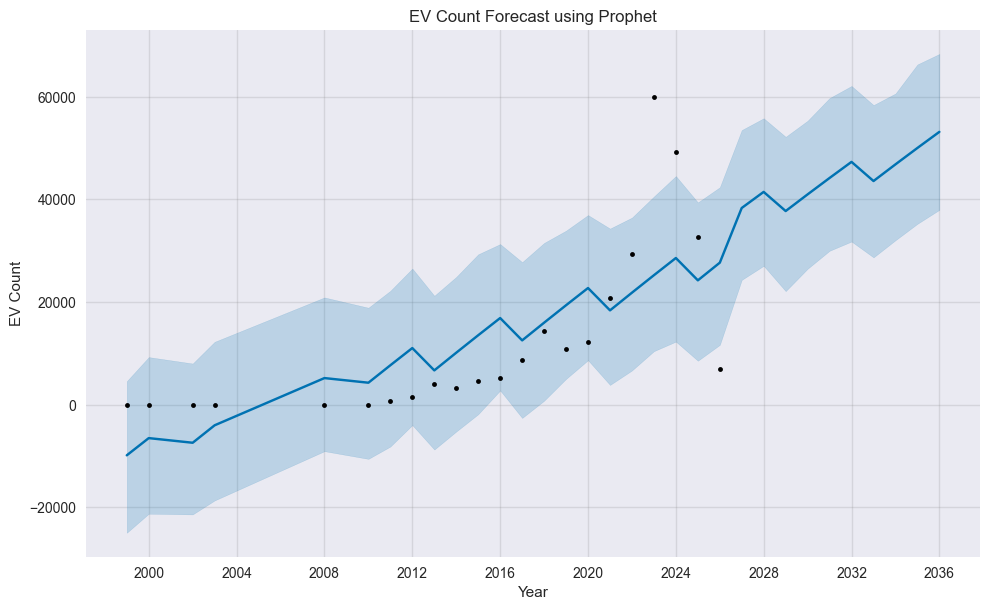

In [ ]:
# visualize prophet forecast
prophet_model.plot(forecast)
plt.title("EV Count Forecast using Prophet")
plt.xlabel("Year")
plt.ylabel("EV Count")
plt.show()


In [ ]:
# compare model

comparison = pd.DataFrame({
    "Model": ["ARIMA Baseline", "ARIMA Optimized"],
    "MAE": [mae_arima, mae_opt],
    "RMSE": [rmse_arima, rmse_opt]
})

comparison


,Model,MAE,RMSE
0,ARIMA Baseline,19327.299209,22521.877023
1,ARIMA Optimized,124480.815923,183805.540936


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [ ]:
# Copy dataset sạch từ phần trước
df_cluster = df.copy()

# Tạo dataset theo City
city_cluster = df_cluster.groupby("City").agg(
    EV_Count=("City", "count"),
    Avg_MSRP=("Base MSRP", "mean"),
    Avg_Range=("Electric Range", "mean"),
    BEV_Ratio=("Electric Vehicle Type", 
               lambda x: (x == "BATTERY ELECTRIC VEHICLE").mean())
).reset_index()

city_cluster.head()


In [ ]:
features = ["EV_Count", "Avg_MSRP", "Avg_Range", "BEV_Ratio"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(city_cluster[features])


In [ ]:
sil_scores = {}
db_scores = {}

for k in range(3, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    sil = silhouette_score(X_scaled, labels)
    db  = davies_bouldin_score(X_scaled, labels)
    
    sil_scores[k] = sil
    db_scores[k] = db
    
    print(f"K={k} | Silhouette={sil:.4f} | Davies-Bouldin={db:.4f}")


In [ ]:
k_opt = 3

kmeans_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
city_cluster["Cluster"] = kmeans_final.fit_predict(X_scaled)

city_cluster.head()


In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=city_cluster,
    x="EV_Count",
    y="Avg_Range",
    hue="Cluster",
    palette="Set2",
    s=80
)

plt.title("Clustering Cities by EV Market Development")
plt.xlabel("Total EV Count")
plt.ylabel("Average Electric Range")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()


In [ ]:
cluster_summary = city_cluster.groupby("Cluster")[features].mean()
cluster_summary


In [ ]:
sil_final = silhouette_score(X_scaled, city_cluster["Cluster"])
db_final  = davies_bouldin_score(X_scaled, city_cluster["Cluster"])

print(f"Final Silhouette Score: {sil_final:.4f}")
print(f"Final Davies-Bouldin Index: {db_final:.4f}")
